# Multimodal Topic Mining and Image Classification
## Advanced Customer Analytics - Visual Data Predictions Assignment


In [ ]:
# Install required packages
# !pip install -q bertopic
# !pip install -q scikit-learn
# !pip install -q pillow
# !pip install -q pandas
# !pip install -q matplotlib
# !pip install -q seaborn
# !pip install -q requests
# !pip install -q tqdm
# !pip install -q datasets
# !pip install -q kaggle


In [8]:
import os
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import zipfile
import subprocess


In [90]:
def download_and_process_pokemon_cards(save_dir='pokemon_cards', num_cards=1000):
    """
    Download Pokemon TCG dataset from Kaggle and download card images.
    Everything is saved in a single directory.
    
    Args:
        save_dir: Directory to save everything (images and metadata)
        num_cards: Number of cards to process
        
    Returns:
        df_final: Processed dataframe with image paths
    """
    
    # Create directory structure
    os.makedirs(f"{save_dir}/images", exist_ok=True)
    temp_dir = f"{save_dir}/temp"
    os.makedirs(temp_dir, exist_ok=True)
    
    # Step 1: Download dataset from Kaggle
    print("Downloading Pokemon TCG dataset from Kaggle...")
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'adampq/pokemon-tcg-all-cards-1999-2023', '-p', temp_dir],
        capture_output=True,
        text=True
    )
    
    # Step 2: Extract the dataset
    zip_path = f'{temp_dir}/pokemon-tcg-all-cards-1999-2023.zip'
    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
    
    # Step 3: Load the CSV
    csv_files = [f for f in os.listdir(temp_dir) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError("No CSV files found in dataset directory")
    
    cards_file = f'{temp_dir}/{csv_files[0]}'
    df_raw = pd.read_csv(cards_file)
    print(f"Loaded {len(df_raw)} total cards from Kaggle dataset\n")
    
    # Step 4: Download images for subset
    df = df_raw.head(num_cards).copy()
    print(f"Processing {len(df)} cards...")
    
    successful = []
    failed = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Downloading images"):
        try:
            card_id = row['id']
            set_code, number = card_id.split('-')
            
            downloaded = False
            for url_template in [
                f"https://images.pokemontcg.io/{set_code}/{number}_hires.png",
                f"https://images.pokemontcg.io/{set_code}/{number}.png"
            ]:
                try:
                    response = requests.get(url_template, timeout=10)
                    response.raise_for_status()
                    
                    img = Image.open(BytesIO(response.content)).convert('RGB')
                    img_path = f"{save_dir}/images/card_{idx:05d}.jpg"
                    img.save(img_path, 'JPEG', quality=95)
                    
                    df.at[idx, 'image_path'] = img_path
                    successful.append(idx)
                    downloaded = True
                    break
                except:
                    continue
            
            if not downloaded:
                failed.append(card_id)
                
        except Exception as e:
            failed.append(row.get('id', f'idx_{idx}'))
            continue
    
    # Step 5: Save only the final processed dataset
    df_final = df.loc[successful].copy()
    csv_path = f'{save_dir}/pokemon_cards_metadata.csv'
    df_final.to_csv(csv_path, index=False)
    
    # Step 6: Clean up temporary files
    print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_dir)
    
    print(f"Successfully processed: {len(df_final)} cards")
    print(f"Failed to download: {len(failed)} cards")
    print(f"Images saved to: {save_dir}/images/")
    print(f"Metadata saved to: {csv_path}")
    
    return df_final

In [ ]:
save_dir = 'pokemon_cards'

# Download and process the dataset
df = download_and_process_pokemon_cards(save_dir, num_cards=6000)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df_radfw.columns)}):")
for col in df.columns:
    print(f"  - {col}")

print(f"\nFirst few rows:")
df.head()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Extracting dataset...
Loaded 17172 total cards from Kaggle dataset

Processing 6000 cards...


### Load the dataset and preprocess it

In [11]:
# Load the processed data
cards_df = pd.read_csv('./pokemon_cards/pokemon_cards_metadata.csv')

print(f"Dataset shape: {cards_df.shape}")
print(f"\nColumns: {list(cards_df.columns)}")
cards_df.head()

Dataset shape: (1000, 30)

Columns: ['id', 'set', 'series', 'publisher', 'generation', 'release_date', 'artist', 'name', 'set_num', 'types', 'supertype', 'subtypes', 'level', 'hp', 'evolvesFrom', 'evolvesTo', 'abilities', 'attacks', 'weaknesses', 'retreatCost', 'convertedRetreatCost', 'rarity', 'flavorText', 'nationalPokedexNumbers', 'legalities', 'resistances', 'rules', 'regulationMark', 'ancientTrait', 'image_path']


,id,set,series,publisher,generation,release_date,artist,name,set_num,types,...,convertedRetreatCost,rarity,flavorText,nationalPokedexNumbers,legalities,resistances,rules,regulationMark,ancientTrait,image_path
0,base1-1,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Alakazam,1,['Psychic'],...,3.0,Rare Holo,Its brain can outperform a supercomputer. Its ...,[65],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN,pokemon_cards/images/card_00000.jpg
1,base1-2,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Blastoise,2,['Water'],...,3.0,Rare Holo,A brutal Pokémon with pressurized water jets o...,[9],{'unlimited': 'Legal'},NaN,NaN,NaN,NaN,pokemon_cards/images/card_00001.jpg
2,base1-3,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Chansey,3,['Colorless'],...,1.0,Rare Holo,A rare and elusive Pokémon that is said to bri...,[113],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00002.jpg
3,base1-4,Base,Base,WOTC,First,1/9/1999,Mitsuhiro Arita,Charizard,4,['Fire'],...,3.0,Rare Holo,Spits fire that is hot enough to melt boulders...,[6],{'unlimited': 'Legal'},"[{'type': 'Fighting', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00003.jpg
4,base1-5,Base,Base,WOTC,First,1/9/1999,Ken Sugimori,Clefairy,5,['Colorless'],...,1.0,Rare Holo,Its magical and cute appeal has many admirers....,[35],{'unlimited': 'Legal'},"[{'type': 'Psychic', 'value': '-30'}]",NaN,NaN,NaN,pokemon_cards/images/card_00004.jpg


In [18]:
import ast

def safe_parse_list(value):
    """Convert string representation of list to actual list."""
    if pd.isna(value):
        return None
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return None
    return value

# Parse list columns
list_columns = ['types', 'subtypes', 'retreatCost', 'nationalPokedexNumbers']
for col in list_columns:
    cards_df[f'{col}_parsed'] = cards_df[col].apply(safe_parse_list)

# Extract first type (most important)
cards_df['primary_type'] = cards_df['types_parsed'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

# Extract first subtype
cards_df['primary_subtype'] = cards_df['subtypes_parsed'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
)

# Convert retreat cost to numeric
cards_df['retreat_cost_count'] = cards_df['retreatCost_parsed'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("Parsed list columns")
cards_df[['name', 'primary_type', 'primary_subtype', 'hp', 'rarity']].head(10)

Parsed list columns


,name,primary_type,primary_subtype,hp,rarity
0,Alakazam,Psychic,Stage 2,80.0,Rare Holo
1,Blastoise,Water,Stage 2,100.0,Rare Holo
2,Chansey,Colorless,Basic,120.0,Rare Holo
3,Charizard,Fire,Stage 2,120.0,Rare Holo
4,Clefairy,Colorless,Basic,40.0,Rare Holo
5,Gyarados,Water,Stage 1,100.0,Rare Holo
6,Hitmonchan,Fighting,Basic,70.0,Rare Holo
7,Machamp,Fighting,Stage 2,100.0,Rare Holo
8,Magneton,Lightning,Stage 1,60.0,Rare Holo
9,Mewtwo,Psychic,Basic,60.0,Rare Holo


In [20]:
# Convert HP to numeric (some might be strings)
cards_df['hp_numeric'] = pd.to_numeric(cards_df['hp'], errors='coerce')

# Count attacks
cards_df['num_attacks'] = cards_df['attacks'].apply(
    lambda x: len(safe_parse_list(x)) if pd.notna(x) else 0
)

# Boolean: has weakness/resistance
cards_df['has_weakness'] = cards_df['weaknesses'].notna()
cards_df['has_resistance'] = cards_df['resistances'].notna()

print("Created numeric features")
cards_df[['name', 'hp_numeric', 'num_attacks', 'retreat_cost_count', 'has_weakness']].head(10)

Created numeric features


,name,hp_numeric,num_attacks,retreat_cost_count,has_weakness
0,Alakazam,80.0,1,3,True
1,Blastoise,100.0,1,3,True
2,Chansey,120.0,2,1,True
3,Charizard,120.0,1,3,True
4,Clefairy,40.0,2,1,True
5,Gyarados,100.0,2,3,True
6,Hitmonchan,70.0,2,2,True
7,Machamp,100.0,1,3,True
8,Magneton,60.0,2,1,True
9,Mewtwo,60.0,2,3,True


In [21]:
# Keep only Pokemon cards (they have types and HP)
pokemon_only = cards_df[
    (cards_df['supertype'] == 'Pokémon') & 
    (cards_df['primary_type'].notna())
].copy()

print(f"Original: {len(cards_df)} cards")
print(f"Pokemon only: {len(pokemon_only)} cards")
print(f"\nType distribution:")
print(pokemon_only['primary_type'].value_counts())

Original: 1000 cards
Pokemon only: 800 cards

Type distribution:
primary_type
Grass        178
Colorless    140
Water        126
Psychic       96
Fighting      93
Lightning     75
Fire          70
Metal         11
Darkness      11
Name: count, dtype: int64


In [27]:
print(f"\nDataset size: {len(pokemon_only)} Pokemon cards")

print(f"\nMissing values in key columns:")
key_cols = ['primary_type', 'hp_numeric', 'rarity', 'artist', 'num_attacks']
for col in key_cols:
    missing = pokemon_only[col].isna().sum()
    pct = (missing / len(pokemon_only)) * 100
    print(f"  {col}: {missing} ({pct:.1f}%)")



Dataset size: 800 Pokemon cards

Missing values in key columns:
  primary_type: 0 (0.0%)
  hp_numeric: 0 (0.0%)
  rarity: 18 (2.2%)
  artist: 0 (0.0%)
  num_attacks: 0 (0.0%)


### Bert implementation

In [83]:
from bertopic import BERTopic
from bertopic.backend import MultiModalBackend
from bertopic.representation import VisualRepresentation
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Create text descriptions for each card
# Combine multiple text fields for richer descriptions
def create_card_description(row):
    """Generate cleaner description without trainer/owner names."""
    parts = []
    
    # Basic Pokemon info - remove trainer prefixes
    if pd.notna(row['name']):
        name = row['name']
        for prefix in ["Blaine's ", "Brock's ", "Misty's ", "Sabrina's ", "Koga's ", 
                       "Erika's ", "Giovanni's ", "Lt. Surge's ", "Rocket's ", "Dark "]:
            name = name.replace(prefix, "")
        parts.append(f"Pokemon: {name}")
    
    # Type and category
    if pd.notna(row['primary_type']):
        parts.append(f"Type: {row['primary_type']}")
    
    if pd.notna(row['primary_subtype']):
        parts.append(f"Evolution stage: {row['primary_subtype']}")

    # Evolution stage
    if pd.notna(row['evolvesFrom']):
        parts.append(f"Evolves from: {row['evolvesFrom']}")

    # Generation
    if pd.notna(row['generation']):
        gen_string = row['generation']
        if gen_string == 'First':
            generation = "Generation 1"
        elif gen_string == 'Second':
            generation = "Generation 2"
        elif gen_string == 'Third':
            generation = "Generation 3"
        elif gen_string == 'Fourth':
            generation = "Generation 4"
        elif gen_string == 'Fifth':
            generation = "Generation 5"
        elif gen_string == 'Sixth':
            generation = "Generation 6"
        elif gen_string == 'Seventh':
            generation = "Generation 7"
        elif gen_string == 'Eighth':
            generation = "Generation 8"
        parts.append(generation)

    # Rarity and artist
    if pd.notna(row['rarity']):
        parts.append(f"Rarity: {row['rarity']}")
    if pd.notna(row['artist']):
        parts.append(f"Illustrated by {row['artist']}")
    
    # Stats - categorize HP instead of exact value
    if pd.notna(row['hp_numeric']):
        hp_category = "High HP" if row['hp_numeric'] >= 80 else "Medium HP" if row['hp_numeric'] >= 50 else "Low HP"
        parts.append(hp_category)
    
    # Battle characteristics
    if row['num_attacks'] > 0:
        parts.append(f"{row['num_attacks']} attacks")
    
    if row['retreat_cost_count'] > 0:
        parts.append(f"Retreat cost: {row['retreat_cost_count']}")
    
    # Weakness/Resistance
    if row['has_weakness']:
        parts.append("Has type weakness")
    if row['has_resistance']:
        parts.append("Has type resistance")
    
    return ". ".join(parts)

# Generate descriptions
pokemon_only['description'] = pokemon_only.apply(create_card_description, axis=1)

print(f"Generated descriptions for {len(pokemon_only)} cards")
print("\nSample descriptions:")
for i in range(3):
    print(f"{i+1}. {pokemon_only.iloc[i]['description']}")

Generated descriptions for 800 cards

Sample descriptions:
1. Pokemon: Alakazam. Type: Psychic. Evolution stage: Stage 2. Evolves from: Kadabra. Generation 1. Rarity: Rare Holo. Illustrated by Ken Sugimori. High HP. 1 attacks. Retreat cost: 3. Has type weakness
2. Pokemon: Blastoise. Type: Water. Evolution stage: Stage 2. Evolves from: Wartortle. Generation 1. Rarity: Rare Holo. Illustrated by Ken Sugimori. High HP. 1 attacks. Retreat cost: 3. Has type weakness
3. Pokemon: Chansey. Type: Colorless. Evolution stage: Basic. Generation 1. Rarity: Rare Holo. Illustrated by Ken Sugimori. High HP. 2 attacks. Retreat cost: 1. Has type weakness. Has type resistance


In [84]:
from PIL import Image

def load_image(image_path):
    """Load and return image."""
    try:
        return Image.open(image_path).convert('RGB')
    except Exception as e:
        return None

# Load images
print("Loading images...")
images = []
valid_indices = []

for idx, row in pokemon_only.iterrows():
    img = load_image(row['image_path'])
    if img is not None:
        images.append(img)
        valid_indices.append(idx)

# Filter to only cards with valid images
pokemon_with_images = pokemon_only.loc[valid_indices].reset_index(drop=True)
descriptions = pokemon_with_images['description'].tolist()

print(f"Loaded {len(images)} images successfully")
print(f"Dataset size for BERTopic: {len(pokemon_with_images)} cards")

Loading images...
Loaded 800 images successfully
Dataset size for BERTopic: 800 cards


In [85]:
# Configure the multimodal embedding model
print("Setting up multimodal model...")

# Use CLIP for multimodal embeddings (text + images)
multimodal_model = SentenceTransformer('clip-ViT-B-32')

# Create multimodal backend
multimodal_backend = MultiModalBackend(embedding_model=multimodal_model)

# Configure dimensionality reduction - more conservative settings
umap_model = UMAP(
    n_neighbors=15,      # Increased for larger neighborhoods
    n_components=10,     # Preserve more information
    min_dist=0.0,        # Allow more spreading
    metric='cosine',
    random_state=42
)

# Configure clustering - balanced settings for 12-15 topics
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    cluster_selection_epsilon=0.0,
    prediction_data=True
)

# Configure vectorization
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2)
)

print("Model configuration complete")

Setting up multimodal model...
Model configuration complete


In [86]:
# Create BERTopic model
print("Creating BERTopic model...")

topic_model = BERTopic(
    embedding_model=multimodal_backend,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=True
)

# Fit the model on both text and images
print("\nFitting BERTopic on multimodal data...")
print("This may take several minutes...")

topics, probs = topic_model.fit_transform(
    documents=descriptions,
    images=images
)

print(f"\nInitial topic modeling complete")
print(f"Initial number of topics: {len(set(topics)) - 1}")

# # Reduce to fewer, more meaningful topics
# print("\nReducing topics to 10 final topics...")
# topic_model.reduce_topics(descriptions, nr_topics=10)

# Get reduced topics
topics = topic_model.topics_

print(f"Final number of topics: {len(set(topics)) - 1}")
print(f"Outliers (topic -1): {sum([1 for t in topics if t == -1])}")

# Add topics to dataframe
pokemon_with_images['topic'] = topics

2025-11-18 20:56:08,873 - BERTopic - Embedding - Transforming documents to embeddings.


Creating BERTopic model...

Fitting BERTopic on multimodal data...
This may take several minutes...


100%|██████████| 25/25 [00:08<00:00,  2.83it/s]
2025-11-18 20:56:20,878 - BERTopic - Embedding - Completed ✓
2025-11-18 20:56:20,878 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-18 20:56:22,024 - BERTopic - Dimensionality - Completed ✓
2025-11-18 20:56:22,024 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-18 20:56:22,038 - BERTopic - Cluster - Completed ✓
2025-11-18 20:56:22,040 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-18 20:56:22,061 - BERTopic - Representation - Completed ✓



Initial topic modeling complete
Initial number of topics: 18
Final number of topics: 18
Outliers (topic -1): 79


In [87]:
# EVALUATION: Topic Quality Assessment
print("TOPIC MODELING RESULTS")
print("-" * 80)

# 1. Basic metrics
num_topics = len(set(topics)) - 1
num_outliers = sum([1 for t in topics if t == -1])
outlier_rate = (num_outliers / len(topics)) * 100

print(f"\nNumber of topics discovered: {num_topics}")
print(f"Outliers: {num_outliers}/{len(topics)} ({outlier_rate:.1f}%)")
print(f"Target: 12-18 topics, <10% outliers")

# 2. Topic purity - does each topic represent ONE Pokemon type?
print("\n" + "-" * 80)
print("TOPIC PURITY (Does each topic = one Pokemon type?)")
print("-" * 80)

for topic_id in sorted([t for t in set(topics) if t != -1]):
    topic_cards = pokemon_with_images[pokemon_with_images['topic'] == topic_id]
    type_dist = topic_cards['primary_type'].value_counts(normalize=True) * 100
    
    dominant_type = type_dist.index[0]
    purity = type_dist.iloc[0]
    count = len(topic_cards)
    
    status = "GOOD" if purity >= 80 else "POOR"
    
    print(f"Topic {topic_id:2d}: {dominant_type:12s} - {count:3d} cards - {purity:5.1f}% pure - {status}")
    
    # Show contamination if impure
    if purity < 80 and len(type_dist) > 1:
        contaminant = type_dist.index[1]
        contaminant_pct = type_dist.iloc[1]
        print(f"          WARNING: {contaminant_pct:.1f}% {contaminant} contamination")

# 3. Type coverage - are all Pokemon types represented?
print("\n" + "-" * 80)
print("TYPE COVERAGE (Does every type have a topic?)")
print("-" * 80)

all_types = pokemon_with_images['primary_type'].value_counts()
print(f"\nTotal types in dataset: {len(all_types)}")

for ptype in all_types.index:
    type_cards = pokemon_with_images[pokemon_with_images['primary_type'] == ptype]
    non_outlier_cards = type_cards[type_cards['topic'] != -1]
    
    if len(non_outlier_cards) > 0:
        main_topic = non_outlier_cards['topic'].mode()[0]
        in_topic = sum(non_outlier_cards['topic'] == main_topic)
        coverage = (in_topic / len(type_cards)) * 100
        status = "GOOD" if coverage >= 70 else "POOR"
        print(f"{ptype:12s}: {len(type_cards):3d} cards -> Topic {main_topic:2d} ({coverage:5.1f}% coverage) - {status}")
    else:
        print(f"{ptype:12s}: {len(type_cards):3d} cards -> NO TOPIC (all outliers) - POOR")

# 4. Summary
print("\n" + "-" * 80)
print("SUMMARY")
print("-" * 80)

good_topics = sum([1 for t in set(topics) if t != -1 and 
                   (pokemon_with_images[pokemon_with_images['topic'] == t]['primary_type'].value_counts(normalize=True).iloc[0] * 100) >= 80])
total_topics = num_topics

print(f"Clean topics (>80% purity): {good_topics}/{total_topics}")
print(f"Outlier rate: {outlier_rate:.1f}% (target: <10%)")

if good_topics >= total_topics * 0.8 and outlier_rate < 10:
    print("\nRESULT: EXCELLENT - Topics are clean and well-separated")
elif good_topics >= total_topics * 0.6 and outlier_rate < 15:
    print("\nRESULT: GOOD - Most topics are clean, some mixing")
else:
    print("\nRESULT: NEEDS IMPROVEMENT - Adjust clustering parameters")

TOPIC MODELING RESULTS
--------------------------------------------------------------------------------

Number of topics discovered: 18
Outliers: 79/800 (9.9%)
Target: 12-18 topics, <10% outliers

--------------------------------------------------------------------------------
TOPIC PURITY (Does each topic = one Pokemon type?)
--------------------------------------------------------------------------------
Topic  0: Grass        - 136 cards -  83.8% pure - GOOD
Topic  1: Water        - 121 cards -  86.8% pure - GOOD
Topic  2: Fire         -  71 cards -  93.0% pure - GOOD
Topic  3: Colorless    -  62 cards -  79.0% pure - POOR
Topic  4: Colorless    -  53 cards -  56.6% pure - POOR
Topic  5: Fighting     -  38 cards -  97.4% pure - GOOD
Topic  6: Colorless    -  32 cards -  93.8% pure - GOOD
Topic  7: Lightning    -  24 cards - 100.0% pure - GOOD
Topic  8: Grass        -  22 cards - 100.0% pure - GOOD
Topic  9: Psychic      -  22 cards -  68.2% pure - POOR
Topic 10: Psychic      -  21 

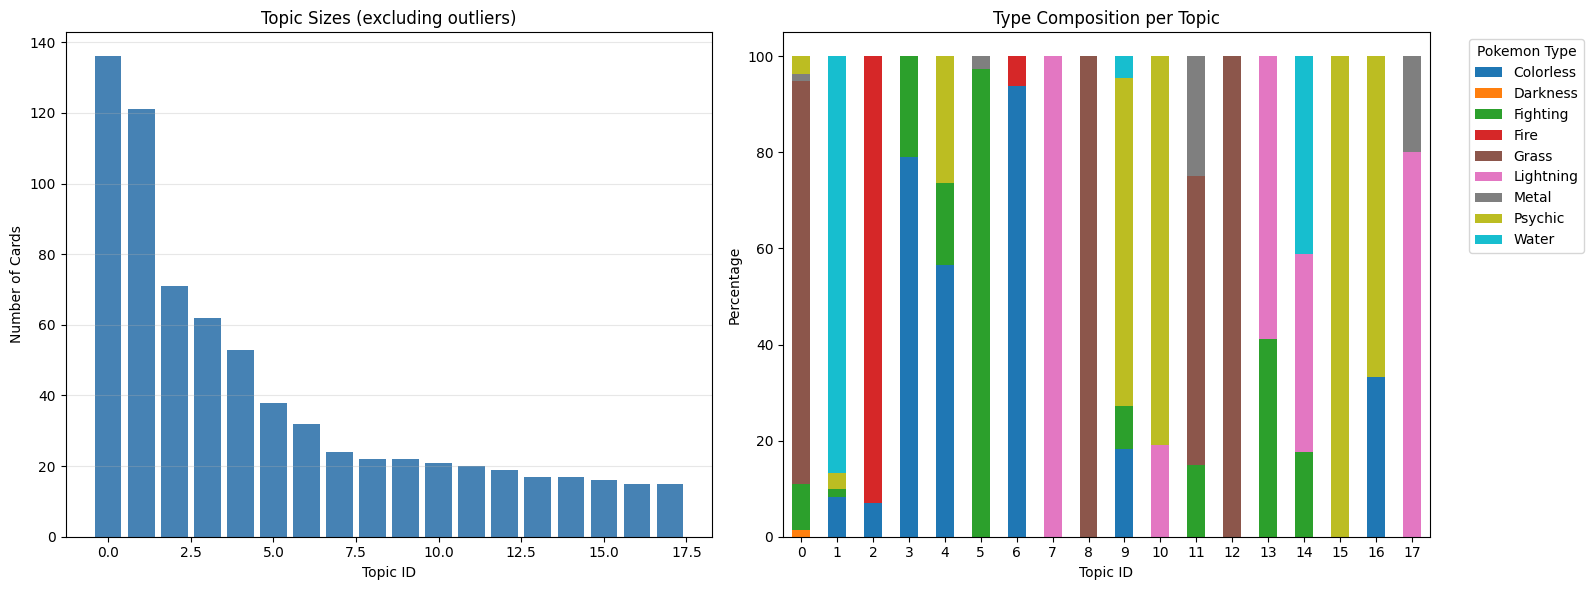

In [88]:
# VISUALIZATION: Topic-Type Alignment
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Topic sizes
topic_counts = pokemon_with_images['topic'].value_counts().sort_index()
topic_counts_no_outliers = topic_counts[topic_counts.index != -1]

axes[0].bar(range(len(topic_counts_no_outliers)), topic_counts_no_outliers.values, color='steelblue')
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Number of Cards')
axes[0].set_title('Topic Sizes (excluding outliers)')
axes[0].grid(axis='y', alpha=0.3)

# Right: Type distribution per topic
topic_type_dist = pd.crosstab(
    pokemon_with_images[pokemon_with_images['topic'] != -1]['topic'],
    pokemon_with_images[pokemon_with_images['topic'] != -1]['primary_type'],
    normalize='index'
) * 100

topic_type_dist.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_xlabel('Topic ID')
axes[1].set_ylabel('Percentage')
axes[1].set_title('Type Composition per Topic')
axes[1].legend(title='Pokemon Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [89]:
# SAMPLE CARDS: What does each topic represent?
print("TOPIC EXAMPLES (First 5 topics)")
print("-" * 80)

for topic_id in range(min(5, len(set(topics)) - 1)):
    topic_cards = pokemon_with_images[pokemon_with_images['topic'] == topic_id]
    
    if len(topic_cards) > 0:
        # Get dominant type
        dominant_type = topic_cards['primary_type'].mode()[0]
        type_pct = (topic_cards['primary_type'] == dominant_type).sum() / len(topic_cards) * 100
        
        print(f"\nTopic {topic_id}: {dominant_type} ({len(topic_cards)} cards, {type_pct:.0f}% purity)")
        print("  Sample cards:")
        for idx, row in topic_cards.head(3).iterrows():
            print(f"    - {row['name']:20s} | Type: {row['primary_type']:10s} | {row['primary_subtype']:8s} | HP: {int(row['hp_numeric']):3d}")
        print()

TOPIC EXAMPLES (First 5 topics)
--------------------------------------------------------------------------------

Topic 0: Grass (136 cards, 84% purity)
  Sample cards:
    - Beedrill             | Type: Grass      | Stage 2  | HP:  80
    - Dugtrio              | Type: Fighting   | Stage 1  | HP:  70
    - Kakuna               | Type: Grass      | Stage 1  | HP:  80


Topic 1: Water (121 cards, 87% purity)
  Sample cards:
    - Blastoise            | Type: Water      | Stage 2  | HP: 100
    - Gyarados             | Type: Water      | Stage 1  | HP: 100
    - Dragonair            | Type: Colorless  | Stage 1  | HP:  80


Topic 2: Fire (71 cards, 93% purity)
  Sample cards:
    - Charizard            | Type: Fire       | Stage 2  | HP: 120
    - Ninetales            | Type: Fire       | Stage 1  | HP:  80
    - Arcanine             | Type: Fire       | Stage 1  | HP: 100


Topic 3: Colorless (62 cards, 79% purity)
  Sample cards:
    - Raticate             | Type: Colorless  | Stage 1 

In [ ]:
def topic_miner(dataset_path, num_topics_target=None, min_cluster_size=15, min_samples=3, show_evaluation=True):
    """
    ASSIGNMENT FUNCTION 1: topic_miner()
    
    Reads dataset and uses BERTopic to identify multimodal topics.
    Labels each image with the topic assigned by BERTopic.

    Args:
        dataset_path: Path to CSV file with Pokemon card metadata
        num_topics_target: Target number of topics (None = automatic)
        min_cluster_size: HDBSCAN parameter for cluster granularity
        min_samples: HDBSCAN parameter for clustering sensitivity
        show_evaluation: Whether to display topic quality evaluation
        
    Returns:
        DataFrame with columns: [image_path, caption, topic_id, topic_label]
    """
    import pandas as pd
    import ast
    from PIL import Image
    from bertopic import BERTopic
    from bertopic.backend import MultiModalBackend
    from sentence_transformers import SentenceTransformer
    from hdbscan import HDBSCAN
    from umap import UMAP
    from sklearn.feature_extraction.text import CountVectorizer
    import numpy as np
    
    def _safe_parse_list(value):
        """Parse string representation of list to actual list."""
        if pd.isna(value):
            return None
        if isinstance(value, str):
            try:
                return ast.literal_eval(value)
            except:
                return None
        return value
    
    def _load_and_preprocess(dataset_path):
        """Load dataset and preprocess to Pokemon-only dataframe."""
        print("\n[1/6] Loading and preprocessing dataset...")
        df = pd.read_csv(dataset_path)
        print(f"   Loaded {len(df)} total cards")
        
        # Parse list columns
        list_columns = ['types', 'subtypes', 'retreatCost', 'nationalPokedexNumbers']
        for col in list_columns:
            df[f'{col}_parsed'] = df[col].apply(_safe_parse_list)
        
        # Extract features
        df['primary_type'] = df['types_parsed'].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
        )
        df['primary_subtype'] = df['subtypes_parsed'].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
        )
        df['retreat_cost_count'] = df['retreatCost_parsed'].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )
        df['hp_numeric'] = pd.to_numeric(df['hp'], errors='coerce')
        df['num_attacks'] = df['attacks'].apply(
            lambda x: len(_safe_parse_list(x)) if pd.notna(x) else 0
        )
        df['has_weakness'] = df['weaknesses'].notna()
        df['has_resistance'] = df['resistances'].notna()
        
        # Filter to Pokemon only
        pokemon_df = df[(df['supertype'] == 'Pokémon') & (df['primary_type'].notna())].copy()
        print(f"   Filtered to {len(pokemon_df)} Pokemon cards")
        
        return pokemon_df
    
    def _generate_captions(df):
        """Generate rich captions for all cards."""
        print("\n[2/6] Generating captions...")
        
        def create_caption(row):
            parts = []
            
            if pd.notna(row['name']):
                name = row['name']
                for prefix in ["Blaine's ", "Brock's ", "Misty's ", "Sabrina's ", "Koga's ", 
                              "Erika's ", "Giovanni's ", "Lt. Surge's ", "Rocket's ", "Dark "]:
                    name = name.replace(prefix, "")
                parts.append(f"Pokemon: {name}")
            
            if pd.notna(row['primary_type']):
                parts.append(f"Type: {row['primary_type']}")
            if pd.notna(row['primary_subtype']):
                parts.append(f"Evolution stage: {row['primary_subtype']}")
            if pd.notna(row['evolvesFrom']):
                parts.append(f"Evolves from: {row['evolvesFrom']}")
            
            if pd.notna(row['generation']):
                gen_map = {'First': 'Generation 1', 'Second': 'Generation 2', 
                          'Third': 'Generation 3', 'Fourth': 'Generation 4',
                          'Fifth': 'Generation 5', 'Sixth': 'Generation 6',
                          'Seventh': 'Generation 7', 'Eighth': 'Generation 8'}
                parts.append(gen_map.get(row['generation'], row['generation']))
            
            if pd.notna(row['rarity']):
                parts.append(f"Rarity: {row['rarity']}")
            if pd.notna(row['artist']):
                parts.append(f"Illustrated by {row['artist']}")
            
            if pd.notna(row['hp_numeric']):
                hp_cat = "High HP" if row['hp_numeric'] >= 80 else "Medium HP" if row['hp_numeric'] >= 50 else "Low HP"
                parts.append(hp_cat)
            
            if row['num_attacks'] > 0:
                parts.append(f"{row['num_attacks']} attacks")
            if row['retreat_cost_count'] > 0:
                parts.append(f"Retreat cost: {row['retreat_cost_count']}")
            if row['has_weakness']:
                parts.append("Has type weakness")
            if row['has_resistance']:
                parts.append("Has type resistance")
            
            return ". ".join(parts)
        
        df['caption'] = df.apply(create_caption, axis=1)
        print(f"   Generated {len(df)} captions")
        return df
    
    def _load_images(df):
        """Load images and filter to valid ones."""
        print("\n[3/6] Loading images...")
        
        images = []
        valid_indices = []
        
        for idx, row in df.iterrows():
            try:
                img = Image.open(row['image_path']).convert('RGB')
                images.append(img)
                valid_indices.append(idx)
            except:
                continue
        
        df_with_images = df.loc[valid_indices].reset_index(drop=True)
        print(f"   Loaded {len(images)} images successfully")
        
        return images, df_with_images
    
    def _build_and_fit_model(descriptions, images, min_cluster_size, min_samples):
        """Build and fit BERTopic model."""
        print("\n[4/6] Building multimodal topic model...")
        
        multimodal_model = SentenceTransformer('clip-ViT-B-32')
        multimodal_backend = MultiModalBackend(embedding_model=multimodal_model)
        
        umap_model = UMAP(
            n_neighbors=15, n_components=10, min_dist=0.0,
            metric='cosine', random_state=42
        )
        
        hdbscan_model = HDBSCAN(
            min_cluster_size=min_cluster_size, min_samples=min_samples,
            metric='euclidean', cluster_selection_method='eom',
            cluster_selection_epsilon=0.0, prediction_data=True
        )
        
        vectorizer_model = CountVectorizer(
            stop_words='english', min_df=2, ngram_range=(1, 2)
        )
        
        topic_model = BERTopic(
            embedding_model=multimodal_backend, umap_model=umap_model,
            hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
            top_n_words=10, verbose=False
        )
        
        print("\n[5/6] Fitting BERTopic (this may take several minutes)...")
        topics, probs = topic_model.fit_transform(documents=descriptions, images=images)
        
        num_topics = len(set(topics)) - 1
        num_outliers = sum([1 for t in topics if t == -1])
        print(f"   ✓ Complete! Topics: {num_topics}, Outliers: {num_outliers}")
        
        return topics, topic_model
    
    def _create_labeled_dataset(df, topics):
        """Create final labeled dataset with topic IDs and labels."""
        print("\n[6/6] Creating labeled dataset...")
        
        df['topic_id'] = topics
        
        # Create topic labels
        topic_names = {}
        for topic_id in sorted([t for t in set(topics) if t != -1]):
            topic_cards = df[df['topic_id'] == topic_id]
            dominant_type = topic_cards['primary_type'].mode()[0] if len(topic_cards) > 0 else "Unknown"
            topic_names[topic_id] = f"Topic_{topic_id}_{dominant_type}"
        topic_names[-1] = "Topic_-1_Outlier"
        
        df['topic_label'] = df['topic_id'].map(topic_names)
        
        result_df = df[['image_path', 'caption', 'topic_id', 'topic_label', 
                        'primary_type', 'primary_subtype', 'hp_numeric', 'name']].copy()
        
        return result_df
    
    def _evaluate_topics(df, topics):
        """Display comprehensive topic quality evaluation."""
        print("\n" + "="*80)
        print("TOPIC MODELING RESULTS - QUALITY EVALUATION")
        print("="*80)
        
        num_topics = len(set(topics)) - 1
        num_outliers = sum([1 for t in topics if t == -1])
        outlier_rate = (num_outliers / len(topics)) * 100
        
        print(f"\nNumber of topics discovered: {num_topics}")
        print(f"Outliers: {num_outliers}/{len(topics)} ({outlier_rate:.1f}%)")
        print(f"Target: 12-18 topics, <10% outliers")
        
        # Topic purity
        print("\n" + "-" * 80)
        print("TOPIC PURITY (Does each topic = one Pokemon type?)")
        print("-" * 80)
        
        for topic_id in sorted([t for t in set(topics) if t != -1]):
            topic_cards = df[df['topic_id'] == topic_id]
            type_dist = topic_cards['primary_type'].value_counts(normalize=True) * 100
            
            dominant_type = type_dist.index[0]
            purity = type_dist.iloc[0]
            count = len(topic_cards)
            status = "GOOD" if purity >= 80 else "POOR"
            
            print(f"Topic {topic_id:2d}: {dominant_type:12s} - {count:3d} cards - {purity:5.1f}% pure - {status}")
            
            if purity < 80 and len(type_dist) > 1:
                contaminant = type_dist.index[1]
                contaminant_pct = type_dist.iloc[1]
                print(f"          WARNING: {contaminant_pct:.1f}% {contaminant} contamination")
        
        # Type coverage
        print("\n" + "-" * 80)
        print("TYPE COVERAGE (Does every type have a topic?)")
        print("-" * 80)
        
        all_types = df['primary_type'].value_counts()
        print(f"\nTotal types in dataset: {len(all_types)}")
        
        for ptype in all_types.index:
            type_cards = df[df['primary_type'] == ptype]
            non_outlier = type_cards[type_cards['topic_id'] != -1]
            
            if len(non_outlier) > 0:
                main_topic = non_outlier['topic_id'].mode()[0]
                in_topic = sum(non_outlier['topic_id'] == main_topic)
                coverage = (in_topic / len(type_cards)) * 100
                status = "GOOD" if coverage >= 70 else "POOR"
                print(f"{ptype:12s}: {len(type_cards):3d} cards -> Topic {main_topic:2d} ({coverage:5.1f}% coverage) - {status}")
            else:
                print(f"{ptype:12s}: {len(type_cards):3d} cards -> NO TOPIC (all outliers) - POOR")
        
        # Summary
        print("\n" + "-" * 80)
        print("SUMMARY")
        print("-" * 80)
        
        good_topics = sum([1 for t in set(topics) if t != -1 and 
                          (df[df['topic_id'] == t]['primary_type'].value_counts(normalize=True).iloc[0] * 100) >= 80])
        
        print(f"Clean topics (>80% purity): {good_topics}/{num_topics}")
        print(f"Outlier rate: {outlier_rate:.1f}% (target: <10%)")
        
        if good_topics >= num_topics * 0.8 and outlier_rate < 10:
            print("\nRESULT: EXCELLENT - Topics are clean and well-separated")
        elif good_topics >= num_topics * 0.6 and outlier_rate < 15:
            print("\nRESULT: GOOD - Most topics are clean, some mixing")
        else:
            print("\nRESULT: NEEDS IMPROVEMENT - Adjust clustering parameters")
        
        # Sample cards
        print("\n" + "-" * 80)
        print("TOPIC EXAMPLES (First 5 topics)")
        print("-" * 80)
        
        for topic_id in range(min(5, num_topics)):
            topic_cards = df[df['topic_id'] == topic_id]
            
            if len(topic_cards) > 0:
                dominant_type = topic_cards['primary_type'].mode()[0]
                type_pct = (topic_cards['primary_type'] == dominant_type).sum() / len(topic_cards) * 100
                
                print(f"\nTopic {topic_id}: {dominant_type} ({len(topic_cards)} cards, {type_pct:.0f}% purity)")
                print("  Sample cards:")
                for idx, row in topic_cards.head(3).iterrows():
                    print(f"    - {row['name']:20s} | Type: {row['primary_type']:10s} | {row['primary_subtype']:8s} | HP: {int(row['hp_numeric']):3d}")
        
        print("\n" + "="*80)
    
    # Main execution flow
    print("="*80)
    print("TOPIC_MINER() - ASSIGNMENT FUNCTION 1")
    print("="*80)
    
    pokemon_df = _load_and_preprocess(dataset_path)
    pokemon_df = _generate_captions(pokemon_df)
    images, pokemon_with_images = _load_images(pokemon_df)
    descriptions = pokemon_with_images['caption'].tolist()
    topics, topic_model = _build_and_fit_model(descriptions, images, min_cluster_size, min_samples)
    result_df = _create_labeled_dataset(pokemon_with_images, topics)
    
    if show_evaluation:
        _evaluate_topics(result_df, topics)
    
    print("\n" + "="*80)
    print(f"TOPIC_MINER() COMPLETE - Labeled {len(result_df)} images")
    print("="*80)
    
    return result_df

In [ ]:
# Execute topic_miner on the full dataset
labeled_dataset = topic_miner('./pokemon_cards/pokemon_cards_metadata.csv')

# Display summary
print("\nLabeled dataset preview:")
print(labeled_dataset.head(10))

print("\nTopic distribution:")
print(labeled_dataset['topic_label'].value_counts())

In [ ]:
def predict(labeled_df, approach='multimodal', test_size=0.3, random_state=42):
    """
    ASSIGNMENT FUNCTION 2: predict()
    
    Trains and tests a classifier using BERTopic labels as classes
    and images/captions as feature sources.
    
    Args:
        labeled_df: DataFrame from topic_miner()
        approach: 'multimodal', 'image_only', or 'text_only'
        test_size: Proportion of test set (default 0.3 for 70/30 split)
        random_state: Random seed for reproducibility
        
    Returns:
        confusion_matrix, results_dict
    """
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
    from sentence_transformers import SentenceTransformer
    from PIL import Image
    import numpy as np
    
    def _prepare_data(df):
        """Filter outliers and prepare for train/test split."""
        print("\n[1/5] Preparing data...")
        df_clean = df[df['topic_id'] != -1].copy()
        print(f"   Removed {len(df) - len(df_clean)} outliers")
        print(f"   Training on {len(df_clean)} samples")
        print(f"   Number of classes: {df_clean['topic_id'].nunique()}")
        return df_clean
    
    def _split_data(df, test_size, random_state):
        """Stratified train/test split."""
        print(f"\n[2/5] Splitting data ({int((1-test_size)*100)}% train / {int(test_size*100)}% test)...")
        train_df, test_df = train_test_split(
            df, test_size=test_size, random_state=random_state,
            stratify=df['topic_id']
        )
        print(f"   Train set: {len(train_df)} samples")
        print(f"   Test set: {len(test_df)} samples")
        return train_df, test_df
    
    def _extract_embeddings(df, approach):
        """Extract CLIP embeddings based on approach."""
        model = SentenceTransformer('clip-ViT-B-32')
        
        if approach == 'text_only':
            embeddings = model.encode(df['caption'].tolist(), show_progress_bar=False)
        elif approach == 'image_only':
            images = [Image.open(path).convert('RGB') for path in df['image_path']]
            embeddings = model.encode(images, show_progress_bar=False)
        elif approach == 'multimodal':
            text_emb = model.encode(df['caption'].tolist(), show_progress_bar=False)
            images = [Image.open(path).convert('RGB') for path in df['image_path']]
            image_emb = model.encode(images, show_progress_bar=False)
            embeddings = np.concatenate([text_emb, image_emb], axis=1)
        
        return embeddings
    
    def _train_classifier(X_train, y_train, random_state):
        """Train Logistic Regression classifier."""
        print("\n[4/5] Training Logistic Regression classifier...")
        classifier = LogisticRegression(
            max_iter=1000, random_state=random_state,
            class_weight='balanced', n_jobs=-1
        )
        classifier.fit(X_train, y_train)
        print("   ✓ Training complete")
        return classifier
    
    def _evaluate_classifier(classifier, X_test, y_test, topic_ids):
        """Evaluate and display results."""
        print("\n[5/5] Evaluating model...")
        y_pred = classifier.predict(X_test)
        
        cm = confusion_matrix(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, 
                                       target_names=[f"Topic {t}" for t in topic_ids])
        
        print(f"   Test Accuracy: {accuracy*100:.2f}%")
        
        print("\n" + "="*80)
        print("CLASSIFICATION REPORT")
        print("="*80)
        print(report)
        
        return cm, accuracy, report, y_pred
    
    # Main execution flow
    print("="*80)
    print("PREDICT() - ASSIGNMENT FUNCTION 2")
    print("="*80)
    
    df_clean = _prepare_data(labeled_df)
    train_df, test_df = _split_data(df_clean, test_size, random_state)
    
    print(f"\n[3/5] Extracting {approach} embeddings...")
    X_train = _extract_embeddings(train_df, approach)
    X_test = _extract_embeddings(test_df, approach)
    print(f"   Feature shape: {X_train.shape}")
    
    y_train = train_df['topic_id'].values
    y_test = test_df['topic_id'].values
    topic_ids = sorted(df_clean['topic_id'].unique())
    
    classifier = _train_classifier(X_train, y_train, random_state)
    cm, accuracy, report, y_pred = _evaluate_classifier(classifier, X_test, y_test, topic_ids)
    
    results = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'classification_report': report,
        'approach': approach,
        'train_size': len(train_df),
        'test_size': len(test_df),
        'num_classes': len(topic_ids),
        'topic_ids': topic_ids,
        'y_test': y_test,
        'y_pred': y_pred
    }
    
    print("\n" + "="*80)
    print(f"PREDICT() COMPLETE - Accuracy: {accuracy*100:.2f}%")
    print("="*80)
    
    return cm, results

In [ ]:
# Execute predict on labeled dataset
cm, results = predict(labeled_dataset, approach='multimodal')

In [ ]:
# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Heatmap
sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='Blues', 
            xticklabels=[f"T{t}" for t in results['topic_ids']], 
            yticklabels=[f"T{t}" for t in results['topic_ids']],
            cbar_kws={'label': 'Proportion'}, ax=axes[0])

axes[0].set_title(f"Confusion Matrix\nAccuracy: {results['accuracy']*100:.2f}% | Approach: {results['approach']}")
axes[0].set_ylabel('True Topic')
axes[0].set_xlabel('Predicted Topic')

# Per-topic accuracy
per_topic_acc = cm.diagonal() / cm.sum(axis=1)
axes[1].bar(range(len(per_topic_acc)), per_topic_acc, color='steelblue')
axes[1].set_xlabel('Topic ID')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Per-Topic Classification Accuracy')
axes[1].axhline(y=results['accuracy'], color='r', linestyle='--', 
                label=f'Overall: {results["accuracy"]*100:.1f}%')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()